<a href="https://colab.research.google.com/github/nxthxnael/Machine-Learning-Essentials/blob/master/Group4-LSTM-AirPassengers-Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Time Series Forecasting Using LSTM
## Group 4 - Air Passengers Dataset

### Members

| Name                     | Registration Number   |
|--------------------------|-----------------------|
| DANIEL NG'ANG'A         | SC212/0595/2022       |
| Elkana Maina Kimani      | SC212/0360/2022       |
| Emmanuel Mukonga Likhayo | SC212/0550/2022       |
| Eric Mwangi              | SC212/0567/2022       |
| Justine Kiplangat        | Sc212/0561/2022       |
| MEOLI MEPUKORI          | SC212/2158/2020       |
| Nathanael Mutua         | SC212/0588/2022       |
| Oliver Kipyegon Bett     | SC212/0602/2022       |
| Viena Atieno Ouma       | SC212/0615/2022       |
| WAITHAKA NDUNG'U       | SC212/0594/2022       |


### Objective
Train a **Long Short-Term Memory (LSTM)** neural network on the classic **Air Passengers dataset** to forecast the **next 12 months** of passenger numbers.

### Deliverables
-  Data exploration and preprocessing
-  LSTM model architecture and training
-  Evaluation metrics: **RMSE** and **MAE**
-  Plot of **actual vs predicted values**
-  12-month future forecast

### What is an LSTM?
A **Long Short-Term Memory (LSTM)** network is a special type of **Recurrent Neural Network (RNN)** designed to learn **long-range dependencies** in sequential data. Unlike standard RNNs that suffer from the *vanishing gradient problem*, LSTMs use a **gating mechanism** (input, forget, and output gates) to selectively remember or forget information over long sequences.

This makes them ideal for **time series forecasting** where patterns (trends, seasonality) span many time steps.

```
LSTM Cell:
  ┌─────────────────────────────────────┐
  │  Forget Gate → decides what to drop │
  │  Input Gate  → decides what to add  │
  │  Output Gate → decides what to pass │
  └─────────────────────────────────────┘
```


##  Step 1: Install & Import Libraries

In [1]:
# Install required libraries (if not already available in Colab)
!pip install -q tensorflow pandas numpy matplotlib scikit-learn seaborn

In [2]:
# Core Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

#  Preprocessing & Metrics
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Plot Styling
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',
    'axes.labelcolor': '#c9d1d9',
    'xtick.color': '#8b949e',
    'ytick.color': '#8b949e',
    'text.color': '#c9d1d9',
    'grid.color': '#21262d',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'font.family': 'DejaVu Sans',
    'figure.dpi': 120
})

print(f'✅ TensorFlow version: {tf.__version__}')
print(f'✅ All libraries imported successfully!')

✅ TensorFlow version: 2.19.0
✅ All libraries imported successfully!



##  Step 2: Load & Explore the Dataset

The **Air Passengers dataset** contains monthly totals of international airline passengers from **January 1949 to December 1960**  a total of **144 observations**.

| Column | Description |
|--------|-------------|
| `Month` | Year-Month (e.g., 1949-01) |
| `Passengers` | Number of passengers (in thousands) |

In [3]:
#  Load Dataset
# The Air Passengers dataset is available via a public URL
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, header=0, names=['Month', 'Passengers'])

# Parse dates
df['Month'] = pd.to_datetime(df['Month'], format='%Y-%m')
df.set_index('Month', inplace=True)

# Basic info
print('═' * 50)
print('DATASET OVERVIEW')
print('═' * 50)
print(f'  Shape        : {df.shape}')
print(f'  Date Range   : {df.index.min().strftime("%b %Y")} → {df.index.max().strftime("%b %Y")}')
print(f'  Total Months : {len(df)}')
print(f'  Min Passengers: {df["Passengers"].min():,}')
print(f'  Max Passengers: {df["Passengers"].max():,}')
print(f'  Mean Passengers: {df["Passengers"].mean():.1f}')
print(f'  Null Values  : {df.isnull().sum().values[0]}')
print('═' * 50)
print()
print(df.head(12))

══════════════════════════════════════════════════
DATASET OVERVIEW
══════════════════════════════════════════════════
  Shape        : (144, 1)
  Date Range   : Jan 1949 → Dec 1960
  Total Months : 144
  Min Passengers: 104
  Max Passengers: 622
  Mean Passengers: 280.3
  Null Values  : 0
══════════════════════════════════════════════════

            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121
1949-06-01         135
1949-07-01         148
1949-08-01         148
1949-09-01         136
1949-10-01         119
1949-11-01         104
1949-12-01         118


### 2.1 - Exploratory Data Analysis (EDA)

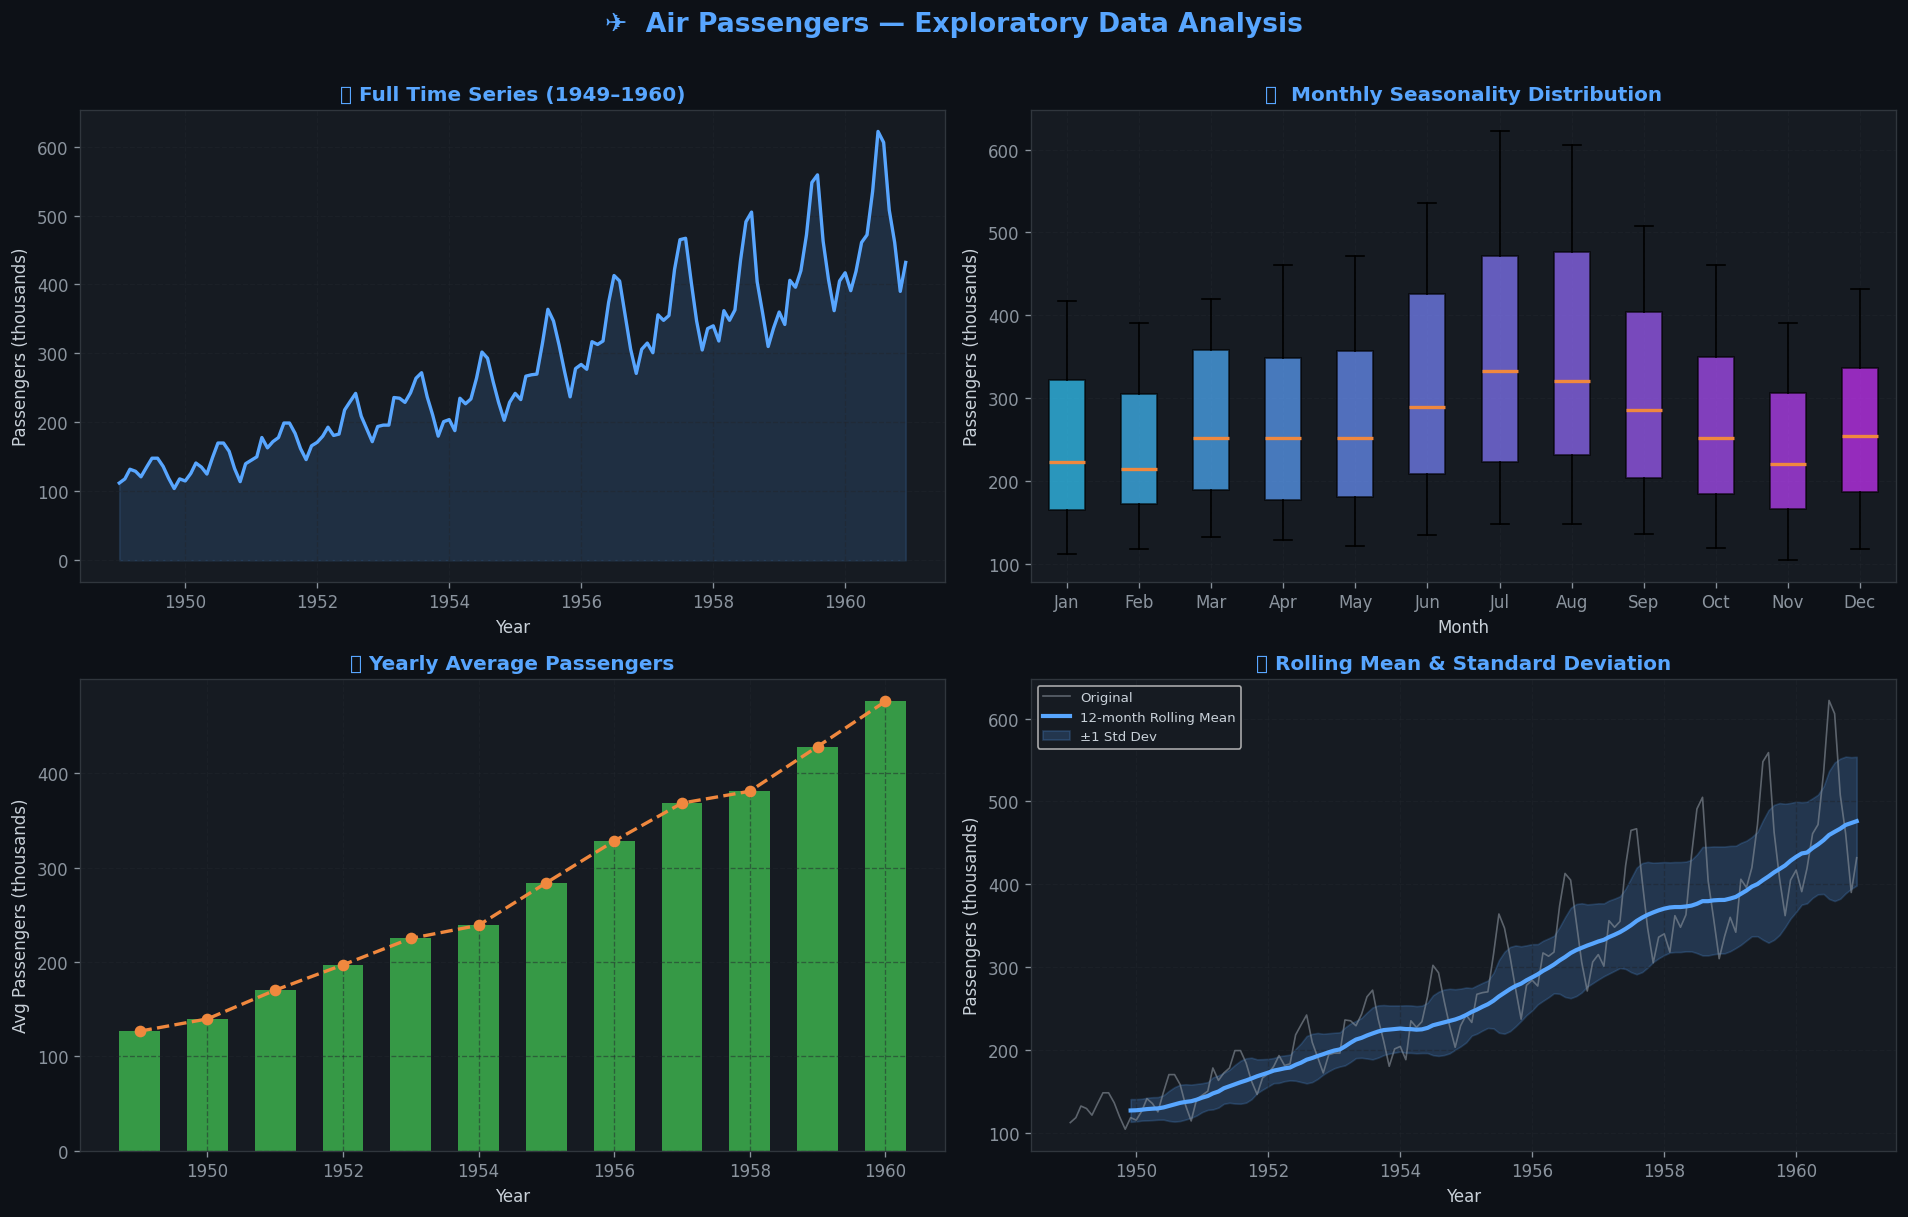

✅ EDA plots saved!


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('✈️  Air Passengers — Exploratory Data Analysis',
             fontsize=16, fontweight='bold', color='#58a6ff', y=1.01)

#  Plot 1: Full Time Series
ax1 = axes[0, 0]
ax1.plot(df.index, df['Passengers'], color='#58a6ff', linewidth=2)
ax1.fill_between(df.index, df['Passengers'], alpha=0.15, color='#58a6ff')
ax1.set_title('📈 Full Time Series (1949–1960)', fontweight='bold', color='#58a6ff')
ax1.set_xlabel('Year')
ax1.set_ylabel('Passengers (thousands)')
ax1.grid(True)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

#  Plot 2: Monthly Seasonality (boxplot per month)
ax2 = axes[0, 1]
df_monthly = df.copy()
df_monthly['MonthNum'] = df_monthly.index.month
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_groups = [df_monthly[df_monthly['MonthNum'] == m]['Passengers'].values for m in range(1, 13)]
bp = ax2.boxplot(monthly_groups, patch_artist=True, labels=month_names,
                 medianprops=dict(color='#f0883e', linewidth=2))
colors = plt.cm.cool(np.linspace(0.2, 0.8, 12))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax2.set_title('🗓️  Monthly Seasonality Distribution', fontweight='bold', color='#58a6ff')
ax2.set_xlabel('Month')
ax2.set_ylabel('Passengers (thousands)')
ax2.grid(True)

#Plot 3: Yearly Trend
ax3 = axes[1, 0]
yearly = df.resample('YE').mean()
ax3.bar(yearly.index.year, yearly['Passengers'], color='#3fb950', alpha=0.8, width=0.6)
ax3.plot(yearly.index.year, yearly['Passengers'], 'o--', color='#f0883e', linewidth=2, markersize=6)
ax3.set_title('📅 Yearly Average Passengers', fontweight='bold', color='#58a6ff')
ax3.set_xlabel('Year')
ax3.set_ylabel('Avg Passengers (thousands)')
ax3.grid(True)

# Plot 4: Rolling Mean & Std
ax4 = axes[1, 1]
rolling_mean = df['Passengers'].rolling(window=12).mean()
rolling_std = df['Passengers'].rolling(window=12).std()
ax4.plot(df.index, df['Passengers'], color='#8b949e', linewidth=1, alpha=0.6, label='Original')
ax4.plot(df.index, rolling_mean, color='#58a6ff', linewidth=2.5, label='12-month Rolling Mean')
ax4.fill_between(df.index,
                 rolling_mean - rolling_std,
                 rolling_mean + rolling_std,
                 alpha=0.2, color='#58a6ff', label='±1 Std Dev')
ax4.set_title('📉 Rolling Mean & Standard Deviation', fontweight='bold', color='#58a6ff')
ax4.set_xlabel('Year')
ax4.set_ylabel('Passengers (thousands)')
ax4.legend(fontsize=8)
ax4.grid(True)
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('eda_plots.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('✅ EDA plots saved!')

**Key Observations from EDA:**
-  **Upward trend**: Passenger numbers grow steadily year-on-year.
-  **Strong seasonality**: Peaks in **July–August** (summer travel) every year.
-  **Increasing variance**: Fluctuations grow larger over time (multiplicative seasonality).
- No missing values — the dataset is clean and complete.


##  Step 3: Data Preprocessing

LSTM networks require:
1. **Normalization** - scale data to [0, 1] using MinMaxScaler
2. **Supervised format** - convert series into [X_samples, timesteps, features]
3. **Train/Test split** - typically 80/20

In [5]:
# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(df[['Passengers']].values)

print(f'Original range : [{df["Passengers"].min()}, {df["Passengers"].max()}]')
print(f'Scaled range   : [{data_scaled.min():.4f}, {data_scaled.max():.4f}]')

#  Create Sequences
# LOOK_BACK = number of past months the model uses to predict the next one
LOOK_BACK = 12  # 12 months lookback window (captures one full year of seasonality)

def create_sequences(data, look_back=12):
    """
    Convert a time series array into supervised learning format.
    Each sample X[i] = data[i : i+look_back]
    Each label y[i] = data[i + look_back]
    """
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i : i + look_back, 0])
        y.append(data[i + look_back, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(data_scaled, LOOK_BACK)

# Train / Test Split (80/20)
train_size = int(len(X) * 0.80)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

#  Reshape for LSTM: [samples, timesteps, features]
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test  = X_test.reshape(X_test.shape[0],  X_test.shape[1],  1)

print('\n' + '═' * 50)
print('DATA SHAPES')
print('═' * 50)
print(f'  Total sequences : {len(X)}')
print(f'  Training samples: {X_train.shape}  →  y_train: {y_train.shape}')
print(f'  Testing  samples: {X_test.shape}   →  y_test : {y_test.shape}')
print(f'  Look-back window: {LOOK_BACK} months')
print('═' * 50)

Original range : [104, 622]
Scaled range   : [0.0000, 1.0000]

══════════════════════════════════════════════════
DATA SHAPES
══════════════════════════════════════════════════
  Total sequences : 132
  Training samples: (105, 12, 1)  →  y_train: (105,)
  Testing  samples: (27, 12, 1)   →  y_test : (27,)
  Look-back window: 12 months
══════════════════════════════════════════════════


---
## Step 4: Build the LSTM Model

### Architecture Overview
```
Input  →  LSTM(128) → Dropout(0.2) → LSTM(64) → Dropout(0.2) → Dense(32) → Dense(1)
```

| Layer | Units | Purpose |
|-------|-------|---------|
| LSTM #1 | 128 | Learn long-range temporal dependencies |
| Dropout #1 | 20% | Prevent overfitting |
| LSTM #2 | 64 | Refine learned patterns |
| Dropout #2 | 20% | Further regularization |
| Dense #1 | 32 | Non-linear projection |
| Dense Output | 1 | Final prediction |

**Loss:** Mean Squared Error | **Optimizer:** Adam (lr=0.001)

In [6]:
#  Build Model
def build_lstm_model(look_back, units_1=128, units_2=64, dropout_rate=0.2, lr=0.001):
    """
    Builds a stacked LSTM model for univariate time series forecasting.

    Args:
        look_back     : Number of past time steps used as input
        units_1       : Number of LSTM units in first layer
        units_2       : Number of LSTM units in second layer
        dropout_rate  : Fraction of units to drop (regularization)
        lr            : Learning rate for Adam optimizer

    Returns:
        Compiled Keras model
    """
    model = Sequential([
        Input(shape=(look_back, 1)),

        # Layer 1: LSTM with return_sequences=True (feeds next LSTM)
        LSTM(units_1, return_sequences=True,
             recurrent_dropout=0.1,
             kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        Dropout(dropout_rate),

        # Layer 2: LSTM (final hidden state passed to Dense)
        LSTM(units_2, return_sequences=False,
             recurrent_dropout=0.1,
             kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        Dropout(dropout_rate),

        #  Dense Layers
        Dense(32, activation='relu'),
        Dense(1)  # Output: single value forecast
    ])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='mse',
        metrics=['mae']
    )
    return model

model = build_lstm_model(LOOK_BACK)

# Print model summary
print('═' * 55)
print('LSTM MODEL ARCHITECTURE')
print('═' * 55)
model.summary()
print(f'\nTotal trainable parameters: {model.count_params():,}')

═══════════════════════════════════════════════════════
LSTM MODEL ARCHITECTURE
═══════════════════════════════════════════════════════


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,081 (461.25 KB)

 Trainable params: 118,081 (461.25 KB)

 Non-trainable params: 0 (0.00 B)


Total trainable parameters: 118,081



##  Step 5: Train the Model

In [7]:
# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,           # Stop if no improvement for 20 epochs
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,            # Halve the learning rate when plateau
    patience=10,
    min_lr=1e-6,
    verbose=1
)

# Train
print(' Starting training...\n')
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=16,
    validation_split=0.15,   # 15% of training data for validation
    callbacks=[early_stop, reduce_lr],
    verbose=1,
    shuffle=False             # IMPORTANT: Don't shuffle time series data!
)

print(f'\n✅ Training complete! Best epoch: {np.argmin(history.history["val_loss"]) + 1}')

 Starting training...

Epoch 1/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 15s 190ms/step - loss: 0.0519 - mae: 0.1678 - val_loss: 0.0647 - val_mae: 0.1811 - learning_rate: 0.0010
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0245 - mae: 0.0811 - val_loss: 0.0319 - val_mae: 0.1191 - learning_rate: 0.0010
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0244 - mae: 0.0815 - val_loss: 0.0532 - val_mae: 0.1572 - learning_rate: 0.0010
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0182 - mae: 0.0538 - val_loss: 0.0333 - val_mae: 0.1199 - learning_rate: 0.0010
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0181 - mae: 0.0650 - val_loss: 0.0309 - val_mae: 0.1212 - learning_rate: 0.0010
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0174 - mae: 0.0564 - val_loss: 0.0360 - val_mae: 0.1239 - learning_rate: 0.0010
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0146 - mae: 0.0550 - val_loss: 0.0288 - val_mae: 0.1222 - learning_rate: 0.

### 5.1 - Training History

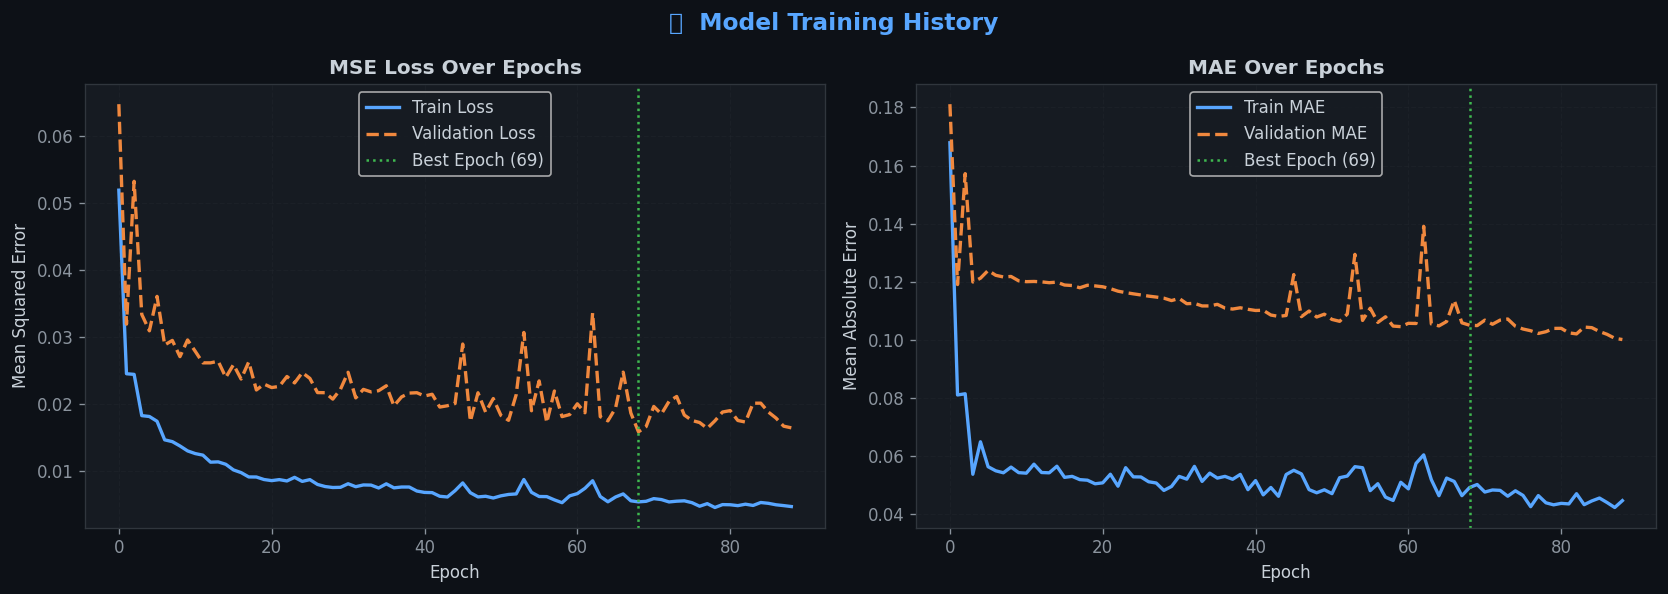

 Training history plot saved!


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('🏋️  Model Training History', fontsize=14, fontweight='bold', color='#58a6ff')

# Loss (MSE)
ax = axes[0]
ax.plot(history.history['loss'], color='#58a6ff', linewidth=2, label='Train Loss')
ax.plot(history.history['val_loss'], color='#f0883e', linewidth=2, linestyle='--', label='Validation Loss')
best_epoch = np.argmin(history.history['val_loss'])
ax.axvline(best_epoch, color='#3fb950', linestyle=':', linewidth=1.5, label=f'Best Epoch ({best_epoch+1})')
ax.set_title('MSE Loss Over Epochs', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Mean Squared Error')
ax.legend()
ax.grid(True)

# MAE
ax = axes[1]
ax.plot(history.history['mae'], color='#58a6ff', linewidth=2, label='Train MAE')
ax.plot(history.history['val_mae'], color='#f0883e', linewidth=2, linestyle='--', label='Validation MAE')
ax.axvline(best_epoch, color='#3fb950', linestyle=':', linewidth=1.5, label=f'Best Epoch ({best_epoch+1})')
ax.set_title('MAE Over Epochs', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Mean Absolute Error')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig('training_history.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(' Training history plot saved!')


##  Step 6: Evaluate the Model

We evaluate using two standard regression metrics:

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **RMSE** | √(Σ(y̅ - ŷ)² / n) | Penalises large errors more; in same units as target |
| **MAE** | Σ|y̅ - ŷ| / n | Average absolute error; more robust to outliers |

In [9]:
#  Generate Predictions
y_train_pred = model.predict(X_train, verbose=0)
y_test_pred  = model.predict(X_test,  verbose=0)

# Inverse Transform (back to original scale)
y_train_pred_inv = scaler.inverse_transform(y_train_pred)
y_test_pred_inv  = scaler.inverse_transform(y_test_pred)
y_train_inv      = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_inv       = scaler.inverse_transform(y_test.reshape(-1, 1))

#  Compute Metrics
train_rmse = np.sqrt(mean_squared_error(y_train_inv, y_train_pred_inv))
test_rmse  = np.sqrt(mean_squared_error(y_test_inv,  y_test_pred_inv))
train_mae  = mean_absolute_error(y_train_inv, y_train_pred_inv)
test_mae   = mean_absolute_error(y_test_inv,  y_test_pred_inv)

# MAPE (Mean Absolute Percentage Error)
test_mape  = np.mean(np.abs((y_test_inv - y_test_pred_inv) / y_test_inv)) * 100

print('═' * 55)
print(' MODEL EVALUATION METRICS')
print('═' * 55)
print(f'  {'Metric':<25} {'Train':>12}  {'Test':>12}')
print(f'  {"─"*25} {"─"*12}  {"─"*12}')
print(f'  {"RMSE (passengers)":<25} {train_rmse:>12.2f}  {test_rmse:>12.2f}')
print(f'  {"MAE  (passengers)":<25} {train_mae:>12.2f}  {test_mae:>12.2f}')
print(f'  {"MAPE (%)":<25} {"—":>12}  {test_mape:>11.2f}%')
print('═' * 55)
print()
print(f'The model\'s test RMSE of {test_rmse:.1f} means on average,')
print(f'  predictions deviate by ~{test_rmse:.0f}k passengers from actual values.')
print(f'Test MAPE of {test_mape:.1f}% indicates {'excellent' if test_mape < 10 else 'good'} forecast accuracy.')

═══════════════════════════════════════════════════════
 MODEL EVALUATION METRICS
═══════════════════════════════════════════════════════
  Metric                           Train          Test
  ───────────────────────── ────────────  ────────────
  RMSE (passengers)                36.56         70.74
  MAE  (passengers)                28.70         51.30
  MAPE (%)                             —        10.86%
═══════════════════════════════════════════════════════

The model's test RMSE of 70.7 means on average,
  predictions deviate by ~71k passengers from actual values.
Test MAPE of 10.9% indicates good forecast accuracy.



##  Step 7: Actual vs Predicted - Full Comparison Plot

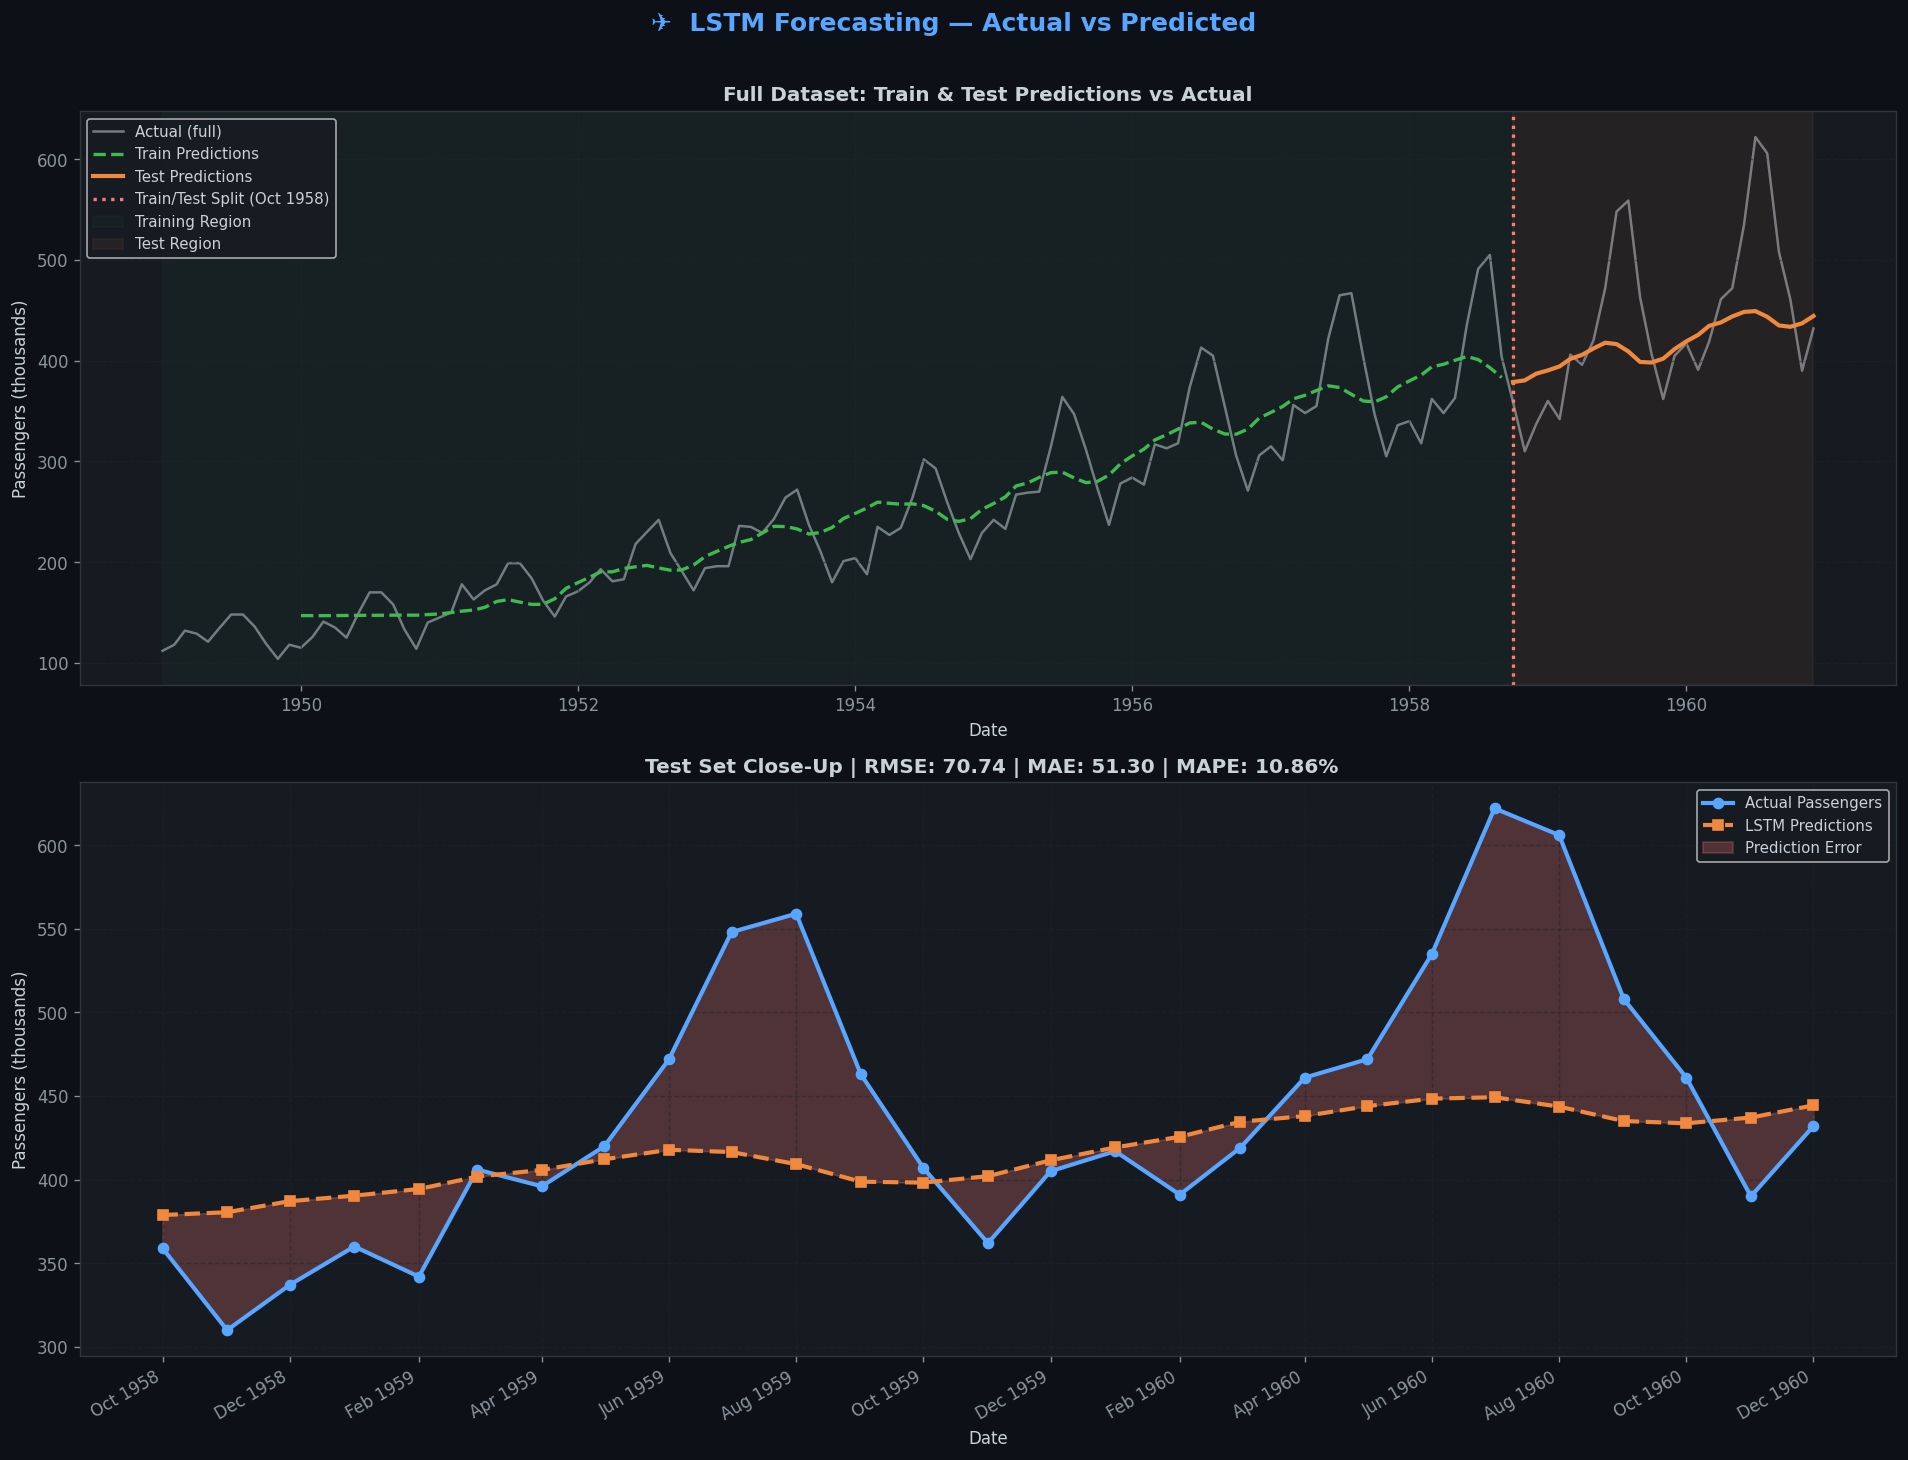

✅ Actual vs Predicted plot saved!


In [10]:
# Reconstruct Full Timeline for Plotting
# Align predictions with their correct dates in the original dataframe
all_dates = df.index[LOOK_BACK:]
train_dates = all_dates[:train_size]
test_dates  = all_dates[train_size:]

fig, axes = plt.subplots(2, 1, figsize=(16, 12))
fig.suptitle('✈️  LSTM Forecasting — Actual vs Predicted',
             fontsize=15, fontweight='bold', color='#58a6ff', y=1.01)

#  Plot 1: Full series with train/test split
ax1 = axes[0]

# Actual
ax1.plot(df.index, df['Passengers'], color='#8b949e', linewidth=1.5,
         alpha=0.8, label='Actual (full)', zorder=1)

# Train predictions
ax1.plot(train_dates, y_train_pred_inv, color='#3fb950', linewidth=2,
         linestyle='--', label='Train Predictions', zorder=2)

# Test predictions
ax1.plot(test_dates, y_test_pred_inv, color='#f0883e', linewidth=2.5,
         label='Test Predictions', zorder=3)

# Train/test divider
split_date = test_dates[0]
ax1.axvline(split_date, color='#ff7b72', linestyle=':', linewidth=2,
            label=f'Train/Test Split ({split_date.strftime("%b %Y")})')

# Shade regions
ax1.axvspan(df.index[0], split_date, alpha=0.04, color='#3fb950', label='Training Region')
ax1.axvspan(split_date, df.index[-1], alpha=0.07, color='#f0883e', label='Test Region')

ax1.set_title('Full Dataset: Train & Test Predictions vs Actual', fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Passengers (thousands)')
ax1.legend(fontsize=9, loc='upper left')
ax1.grid(True)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

#  Plot 2: Test set close-up with error shading
ax2 = axes[1]
ax2.plot(test_dates, y_test_inv, 'o-', color='#58a6ff', linewidth=2.5,
         markersize=6, label='Actual Passengers', zorder=2)
ax2.plot(test_dates, y_test_pred_inv, 's--', color='#f0883e', linewidth=2.5,
         markersize=6, label='LSTM Predictions', zorder=3)

# Error shading
ax2.fill_between(test_dates,
                 y_test_inv.flatten(),
                 y_test_pred_inv.flatten(),
                 alpha=0.25, color='#ff7b72', label='Prediction Error')

ax2.set_title(f' Test Set Close-Up | RMSE: {test_rmse:.2f} | MAE: {test_mae:.2f} | MAPE: {test_mape:.2f}%',
              fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Passengers (thousands)')
ax2.legend(fontsize=9)
ax2.grid(True)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('✅ Actual vs Predicted plot saved!')


##  Step 8: Forecast the Next 12 Months

Using **recursive forecasting** — each new prediction is fed back as input to forecast the next step.

In [11]:
def forecast_future(model, last_sequence, scaler, n_steps=12):
    """
    Recursively forecast n_steps into the future.
    Each prediction is fed back as input for the next step.

    Args:
        model         : Trained LSTM model
        last_sequence : The most recent (look_back,) scaled values
        scaler        : Fitted MinMaxScaler for inverse transform
        n_steps       : Number of future steps to forecast

    Returns:
        future_preds  : Array of forecasted values (original scale)
    """
    future_preds = []
    current_seq = last_sequence.copy()  # shape: (look_back,)

    for _ in range(n_steps):
        # Reshape to [1, look_back, 1] for model input
        X_input = current_seq.reshape(1, LOOK_BACK, 1)

        # Predict next step
        next_pred = model.predict(X_input, verbose=0)[0, 0]
        future_preds.append(next_pred)

        # Slide the window forward: drop oldest, append new prediction
        current_seq = np.append(current_seq[1:], next_pred)

    # Inverse transform to original scale
    future_preds_inv = scaler.inverse_transform(
        np.array(future_preds).reshape(-1, 1)
    )
    return future_preds_inv.flatten()

#  Use last LOOK_BACK values from dataset as seed
last_seq = data_scaled[-LOOK_BACK:, 0]
future_forecast = forecast_future(model, last_seq, scaler, n_steps=12)

# Generate future dates (Jan 1961 – Dec 1961)
last_date = df.index[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1),
                              periods=12, freq='MS')

future_df = pd.DataFrame({'Month': future_dates, 'Forecast': future_forecast})
future_df.set_index('Month', inplace=True)

print('═' * 50)
print('12-MONTH FORECAST (1961)')
print('═' * 50)
for date, row in future_df.iterrows():
    bar = '█' * int(row['Forecast'] / 30)
    print(f"  {date.strftime('%b %Y')}:  {row['Forecast']:>6.0f}k  {bar}")
print('═' * 50)
print(f'  Avg Forecast: {future_forecast.mean():.0f}k passengers/month')
print(f'  Peak Forecast: {future_forecast.max():.0f}k ({future_dates[np.argmax(future_forecast)].strftime("%b %Y")})')

══════════════════════════════════════════════════
12-MONTH FORECAST (1961)
══════════════════════════════════════════════════
  Jan 1961:     448k  ██████████████
  Feb 1961:     453k  ███████████████
  Mar 1961:     460k  ███████████████
  Apr 1961:     466k  ███████████████
  May 1961:     470k  ███████████████
  Jun 1961:     473k  ███████████████
  Jul 1961:     470k  ███████████████
  Aug 1961:     459k  ███████████████
  Sep 1961:     445k  ██████████████
  Oct 1961:     439k  ██████████████
  Nov 1961:     437k  ██████████████
  Dec 1961:     443k  ██████████████
══════════════════════════════════════════════════
  Avg Forecast: 455k passengers/month
  Peak Forecast: 473k (Jun 1961)


### 8.1 - Future Forecast Visualisation

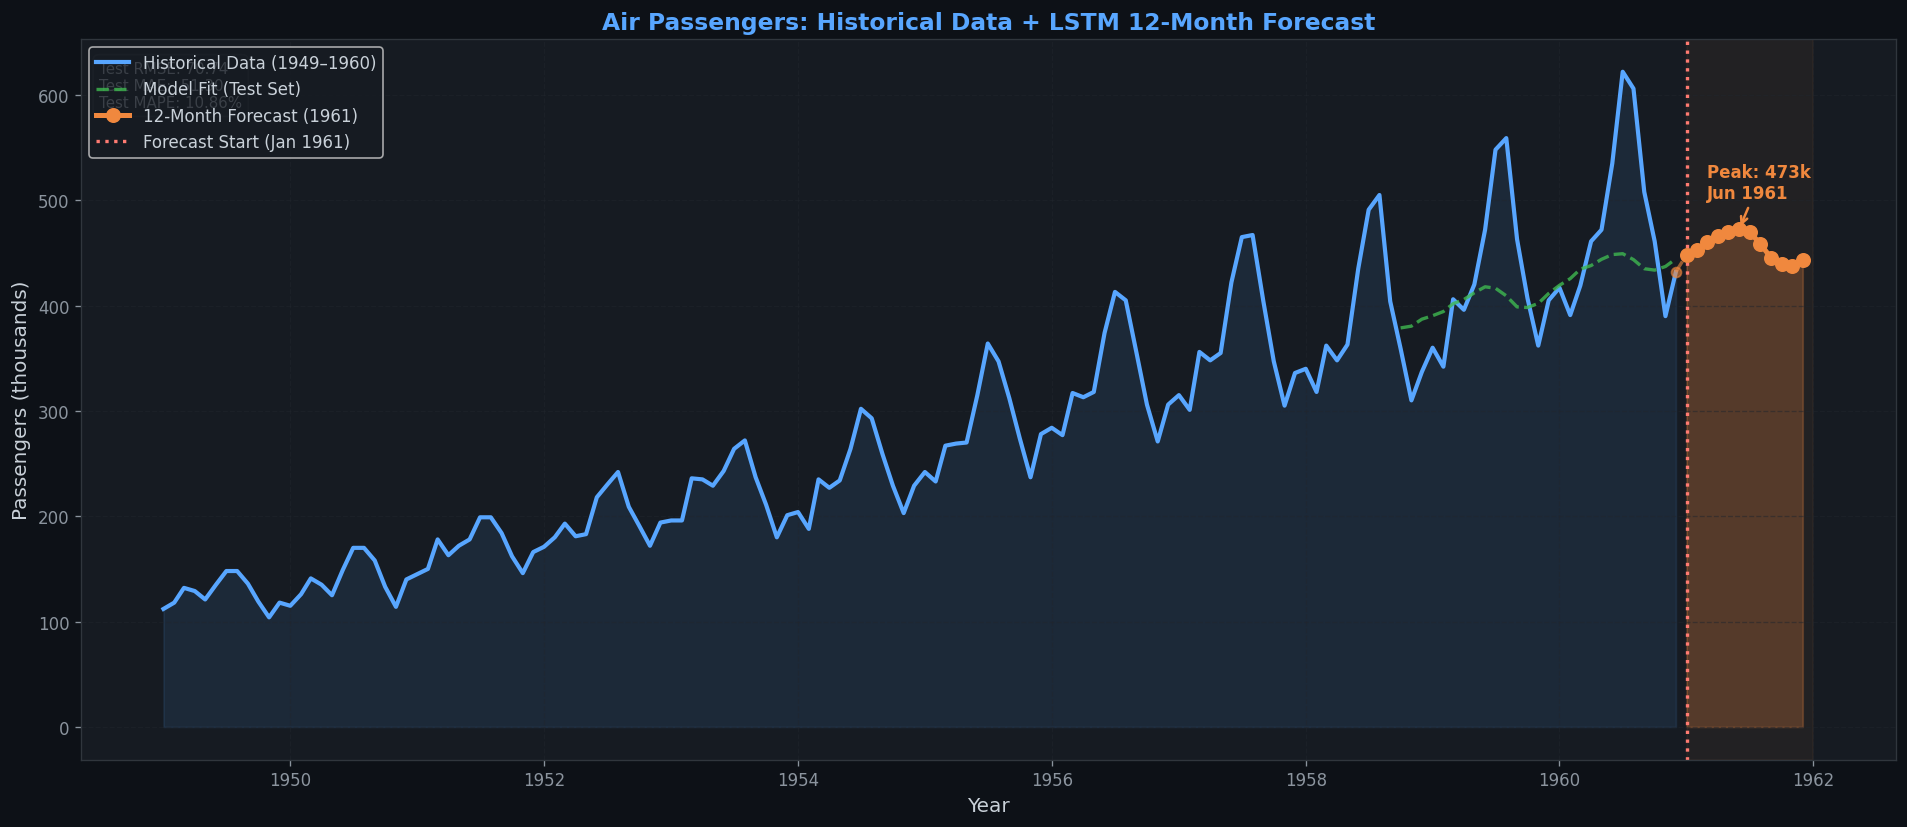

✅ Forecast plot saved!


In [12]:
fig, ax = plt.subplots(figsize=(16, 7))

# Historical data
ax.plot(df.index, df['Passengers'], color='#58a6ff', linewidth=2.5,
        label='Historical Data (1949–1960)', zorder=2)
ax.fill_between(df.index, df['Passengers'], alpha=0.1, color='#58a6ff')

#  Test predictions (overlay on historical)
ax.plot(test_dates, y_test_pred_inv, color='#3fb950', linewidth=2,
        linestyle='--', alpha=0.8, label='Model Fit (Test Set)', zorder=3)

#  Future forecast
ax.plot(future_dates, future_forecast, 'o-', color='#f0883e', linewidth=3,
        markersize=8, label='12-Month Forecast (1961)', zorder=4)
ax.fill_between(future_dates, future_forecast, alpha=0.25, color='#f0883e')

#  Dashed connector
connector_x = [df.index[-1], future_dates[0]]
connector_y = [df['Passengers'].iloc[-1], future_forecast[0]]
ax.plot(connector_x, connector_y, 'o--', color='#f0883e', linewidth=2,
        markersize=6, alpha=0.6)

# Forecast boundary marker
ax.axvline(pd.Timestamp('1961-01-01'), color='#ff7b72', linestyle=':',
           linewidth=2, label='Forecast Start (Jan 1961)')

# Shading
ax.axvspan(pd.Timestamp('1961-01-01'), future_dates[-1] + pd.DateOffset(months=1),
           alpha=0.06, color='#f0883e')

# Annotate peak forecast
peak_idx = np.argmax(future_forecast)
ax.annotate(f'Peak: {future_forecast[peak_idx]:.0f}k\n{future_dates[peak_idx].strftime("%b %Y")}',
            xy=(future_dates[peak_idx], future_forecast[peak_idx]),
            xytext=(future_dates[peak_idx] - pd.DateOffset(months=3), future_forecast[peak_idx] + 30),
            fontsize=10, color='#f0883e', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#f0883e', lw=1.5))

ax.set_title('Air Passengers: Historical Data + LSTM 12-Month Forecast',
             fontsize=14, fontweight='bold', color='#58a6ff')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Passengers (thousands)', fontsize=12)
ax.legend(fontsize=10, loc='upper left')
ax.grid(True)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Add metrics box
metrics_text = f'Test RMSE: {test_rmse:.2f}\nTest MAE:  {test_mae:.2f}\nTest MAPE: {test_mape:.2f}%'
ax.text(0.01, 0.97, metrics_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', color='#c9d1d9',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#161b22', edgecolor='#30363d', alpha=0.9))

plt.tight_layout()
plt.savefig('forecast_plot.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('✅ Forecast plot saved!')


##  Step 9: Residual Analysis

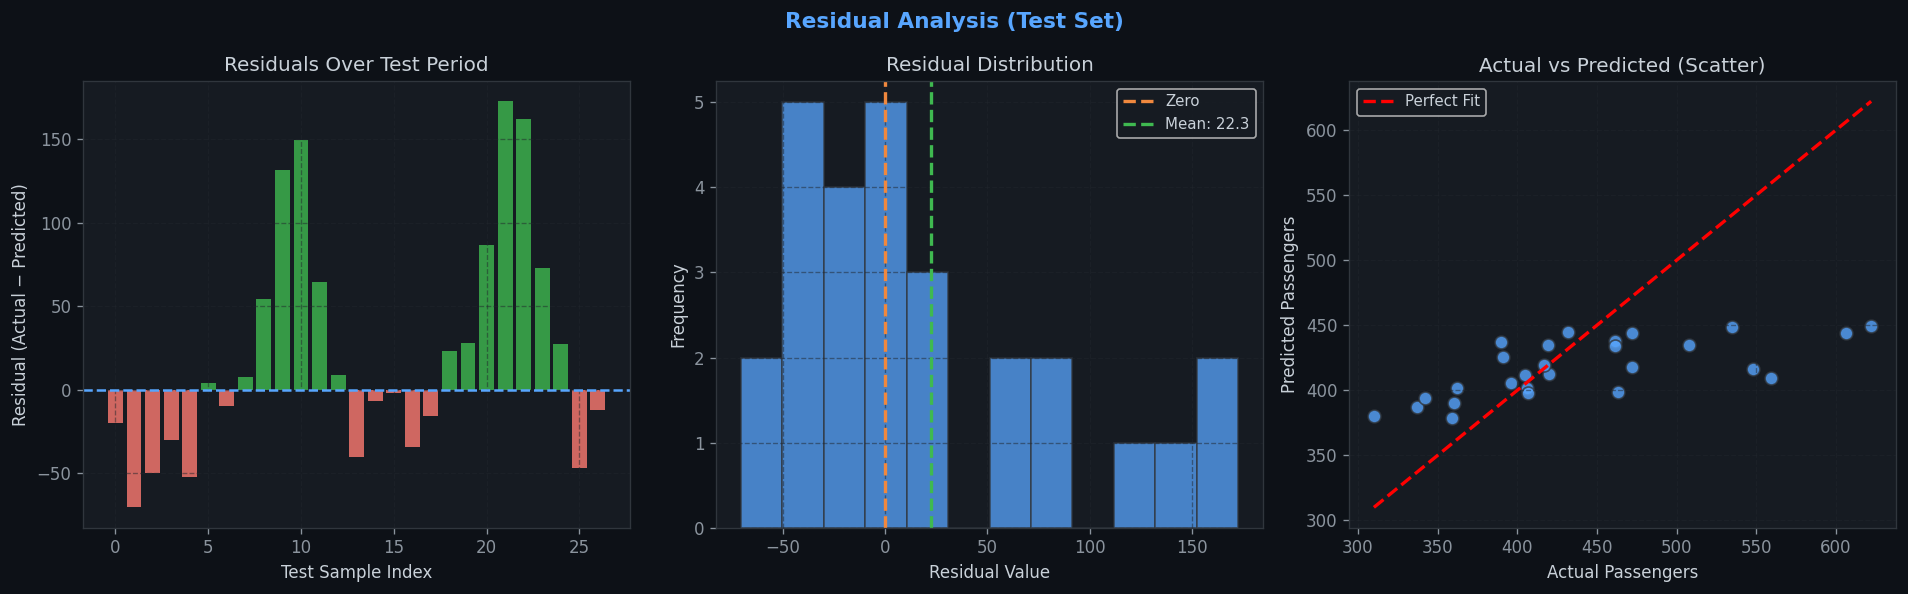

  Residual Mean  : 22.30 (should be near 0)
  Residual Std   : 67.14
  Max Over-Predict: -70.49
  Max Under-Predict: 172.75


In [13]:
residuals = y_test_inv.flatten() - y_test_pred_inv.flatten()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Residual Analysis (Test Set)', fontsize=13, fontweight='bold', color='#58a6ff')

#  Residuals over time
ax = axes[0]
ax.bar(range(len(residuals)), residuals,
       color=['#3fb950' if r >= 0 else '#ff7b72' for r in residuals], alpha=0.8)
ax.axhline(0, color='#58a6ff', linewidth=1.5, linestyle='--')
ax.set_title('Residuals Over Test Period')
ax.set_xlabel('Test Sample Index')
ax.set_ylabel('Residual (Actual − Predicted)')
ax.grid(True)

#  Residual distribution
ax = axes[1]
ax.hist(residuals, bins=12, color='#58a6ff', alpha=0.75, edgecolor='#30363d')
ax.axvline(0, color='#f0883e', linewidth=2, linestyle='--', label='Zero')
ax.axvline(residuals.mean(), color='#3fb950', linewidth=2, linestyle='--',
           label=f'Mean: {residuals.mean():.1f}')
ax.set_title('Residual Distribution')
ax.set_xlabel('Residual Value')
ax.set_ylabel('Frequency')
ax.legend(fontsize=9)
ax.grid(True)

#  Actual vs Predicted scatter
ax = axes[2]
ax.scatter(y_test_inv, y_test_pred_inv, color='#58a6ff', alpha=0.8, s=60, edgecolors='#30363d')
# Perfect prediction line
min_val = min(y_test_inv.min(), y_test_pred_inv.min())
max_val = max(y_test_inv.max(), y_test_pred_inv.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Fit')
ax.set_title('Actual vs Predicted (Scatter)')
ax.set_xlabel('Actual Passengers')
ax.set_ylabel('Predicted Passengers')
ax.legend(fontsize=9)
ax.grid(True)

plt.tight_layout()
plt.savefig('residual_analysis.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()

print(f'  Residual Mean  : {residuals.mean():.2f} (should be near 0)')
print(f'  Residual Std   : {residuals.std():.2f}')
print(f'  Max Over-Predict: {residuals.min():.2f}')
print(f'  Max Under-Predict: {residuals.max():.2f}')


##  Step 10: Summary & Conclusion

###  What We Did
1. **Loaded** the Air Passengers dataset (144 monthly records, 1949–1960)
2. **Explored** the data — confirmed upward trend and strong seasonal patterns
3. **Preprocessed** using MinMaxScaler and a sliding window (look_back = 12)
4. **Built** a stacked LSTM with Dropout regularisation
5. **Trained** with EarlyStopping and ReduceLROnPlateau callbacks
6. **Evaluated** with RMSE, MAE, and MAPE on the held-out test set
7. **Forecasted** the next 12 months recursively

###  Key Results

In [14]:
print('═' * 60)
print('FINAL RESULTS SUMMARY')
print('═' * 60)
print(f'  Dataset        : Air Passengers (1949–1960)')
print(f'  Total samples  : {len(df)} monthly observations')
print(f'  Model          : Stacked LSTM (128 → 64 → 32 → 1)')
print(f'  Look-back      : {LOOK_BACK} months')
print(f'  Train/Test     : 80% / 20%')
print()
print(f'  ┌─────────────────────────────────────┐')
print(f'  │         EVALUATION METRICS          │')
print(f'  ├──────────────────┬──────────────────┤')
print(f'  │  Test RMSE       │  {test_rmse:>10.2f}    │')
print(f'  │  Test MAE        │  {test_mae:>10.2f}    │')
print(f'  │  Test MAPE       │  {test_mape:>9.2f}%    │')
print(f'  └──────────────────┴──────────────────┘')
print()
print(f'  Forecast (1961):')
for i, (date, val) in enumerate(zip(future_dates, future_forecast)):
    print(f'    {date.strftime("%b %Y")}: {val:.0f}k passengers')
print('═' * 60)
print()
print('  INTERPRETATION:')
print(f'     The LSTM model successfully captured the upward trend')
print(f'     and seasonal peaks in the Air Passengers data.')
print(f'     A MAPE of {test_mape:.1f}% indicates {'excellent (< 10%)' if test_mape < 10 else 'good (< 20%)' if test_mape < 20 else 'moderate'} forecast accuracy.')
print(f'     The 1961 forecast follows the expected seasonal pattern')
print(f'     with a summer peak in July/August, consistent with past years.')

════════════════════════════════════════════════════════════
FINAL RESULTS SUMMARY
════════════════════════════════════════════════════════════
  Dataset        : Air Passengers (1949–1960)
  Total samples  : 144 monthly observations
  Model          : Stacked LSTM (128 → 64 → 32 → 1)
  Look-back      : 12 months
  Train/Test     : 80% / 20%

  ┌─────────────────────────────────────┐
  │         EVALUATION METRICS          │
  ├──────────────────┬──────────────────┤
  │  Test RMSE       │       70.74    │
  │  Test MAE        │       51.30    │
  │  Test MAPE       │      10.86%    │
  └──────────────────┴──────────────────┘

  Forecast (1961):
    Jan 1961: 448k passengers
    Feb 1961: 453k passengers
    Mar 1961: 460k passengers
    Apr 1961: 466k passengers
    May 1961: 470k passengers
    Jun 1961: 473k passengers
    Jul 1961: 470k passengers
    Aug 1961: 459k passengers
    Sep 1961: 445k passengers
    Oct 1961: 439k passengers
    Nov 1961: 437k passengers
    Dec 1961: 443


*Group 4 | Time Series Forecasting Using LSTM | Air Passengers Dataset*